# Fachprojekt Machine Learning - Deep Learning 101
Authors: Sebastian Konietzny, Jan Robine

🔹***Task:*** Train a multi-layer perceptron (MLP) to classify images on the [MNIST dataset](https://paperswithcode.com/dataset/mnist). Fill in the missing code!

---

**Setup with Google Colab:** Access it via their [website](https://colab.research.google.com/).

- Don't let the notebook disconnect during training! This happens when you close the browser tab, or when you lose the internet connection. You are automatically disconnected when the notebook has been running for more than 12 hours. More information on Colab's resource limits can be found [here](https://research.google.com/colaboratory/faq.html#resource-limits).
- When you are **ready** to train the MLP, change the runtime type of this notebook to "GPU":  
"Runtime > Change runtime type" ("Laufzeit > Laufzeittyp ändern"). To save resources, only switch to "GPU" when you are finished with your implementation.
- You need to upload the $\texttt{helper.py}$-file into your runtime environment to be able to import from it. Uncomment the following code cell and select the file to upload it.

In [1]:
# from google.colab import files
# uploaded = files.upload()

**Setup at home:** Install these python libraries.
- Use our `requirements.txt` or install

1. `torch`, `torchvision`  for training neural networks. Get it [here](https://pytorch.org/). Select CUDA for GPU support (usable with **Nvidia** GPUs). Use ROCm for AMD.
2. `matplotlib` for visualizations

---

## Imports

In [2]:
import matplotlib.pyplot as plt
from helper import *

# Deep learning library
import torch
import torchvision

# Use shorthands (nn instead of torch.nn, optim instead of torch.optim)
from torch import nn, optim

## Download MNIST and visualization
🔹***Task:*** Run the code. It downloads the dataset (21MB) into directory "data".

In [3]:
# Normalize the images from [0, 1] to [-1, 1] and flatten them
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,)),
])

# Load the training dataset (for training)
training_data = torchvision.datasets.MNIST(
    root="data", train=True, download=True, transform=transform)

test_data = torchvision.datasets.MNIST(
    root="data", train=False, download=True, transform=transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 132MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 34.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 62.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.92MB/s]


---

## Multi-layer Perceptrons (MLPs)

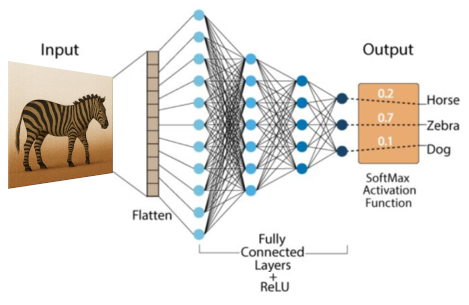

[reference](https://www.researchgate.net/figure/Convolutional-Neural-Network-Illustration-credit-Developers-Breach_fig1_373832377) (+ edits)

**General MLP architecture:**

**Input**: One or multiple 2D images with tensor shape `(batch_size, color_channels, height, width)`. For MNIST: `(batch_size, 1, 28, 28)`.

1. Flatten the image to a 1D vector using `nn.Flatten`.
   
   Flatten Shape: `(batch_size, color_channels*height*width)`

2. Use fully connected layers (`nn.Linear`) to process the feature vector. Follow each fully connected layer with an activation function (e.g. `nn.ReLU`).

   Output Shape: `(batch_size, number_of_image_classes)`.

**🔍 Hints:**
- Fully connected layers (`nn.Linear`) with alot units are expensive to train. Do not use more than `512` for a layer, better less.

- Don't forget activation functions after `nn.Linear`. But not after the output.

- Big networks get (usually) better results! But they need more compute time. Start with a small network for debugging.

🔹***Task:*** Add the missing code.

In [4]:
class MLP(nn.Module):

  def __init__(self):
    super().__init__()

    self.mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

    ################################################

  def forward(self, imgs):
    '''
    Arguments:
      imgs torch.Tensor: images of shape (batch_size, 1, 28, 28).
    Returns:
      torch.Tensor: predictions of shape (batch_size, 10).
    '''
    ################################################
    return self.mlp(imgs)
    ################################################

  def predict(self, imgs):
    scores = self.forward(imgs)
    return torch.argmax(scores, dim=1)
    '''
    Arguments:
      imgs torch.Tensor: images of shape (batch_size, 1, 28, 28).
    Returns:
      torch.Tensor: predicted class indices of shape (batch_size).
    '''
    ################################################
    # Use the network to predict a class for each image.
    # Apply torch.argmax() on the output scores to get the predictions.
    # TODO

    ################################################

## Test the network class

🔔 **Important:**

When you change your neural network above, make sure to run the code cell again, before running the cell below!  
Otherwise the old neural network code will be used.

🔹***Task:*** Run the code to check if your neural network functions are correct. Your network design from `__init__()` is not checked.

In [5]:
mlp_test = MLP().eval()
ok = check_network(mlp_test, input_shape=(1, 28, 28), num_classes=10)

All checks passed! Move on!


## MLP Optimization
In order to train the MLP we have to do the following:

Given: images, labels

1. Compute the outputs of the neural network. Don't use predict().
2. Compute the loss function. Use `nn.functional.cross_entropy()`.
3. Compute the gradients for the loss function.
4. Update the network by using the optimizer.
5. Reset the gradients by using the optimizer.

🔹***Task:*** Implement the function below.

In [6]:
def training_step(network, images, labels, optimizer):

    """
    Args:
        network (torch.nn.Module): The neural network.
        images (torch.Tensor): Input batch of images with shape (batch_size, 1, 28, 28).
        labels (torch.Tensor): Corresponding labels for the images with shape (batch_size).
        optimizer (torch.optim.Optimizer): Optimizer for updating neural network weights.

    Returns:
        torch.Tensor: a single loss value for the current batch with shape (1). When returning, apply .detach() on the loss value.
    """

    ################################################
    outputs = network(images)

    loss = nn.functional.cross_entropy(outputs, labels)

    loss.backward()

    optimizer.step()

    optimizer.zero_grad()

    return loss
    ################################################

## Let's Go. Everything is done. Run the train function below. 🏋️

To pass this homework, you need to achieve an accuracy of **at least 96%**! Try out, or research on the internet how to build and train neural networks properly.

Using CPU


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch:   1/ 10, Batch     1, Loss: 2.3059
Epoch:   1/ 10, Batch   101, Loss: 0.9562
Epoch:   1/ 10, Batch   201, Loss: 0.4400
Epoch:   1/ 10, Batch   301, Loss: 0.3715
Epoch:   1/ 10, Batch   401, Loss: 0.3446
Epoch:   1/ 10, Batch   501, Loss: 0.3170
Epoch:   1/ 10, Batch   601, Loss: 0.3090
Epoch:   1/ 10, Batch   701, Loss: 0.2588
Epoch:   1/ 10, Batch   801, Loss: 0.2495
Epoch:   1/ 10, Batch   901, Loss: 0.2468
Correct: 9327/10000, Accuracy: (93.270%)
Epoch took 17.33 seconds
Epoch:   2/ 10, Batch     1, Loss: 0.1861
Epoch:   2/ 10, Batch   101, Loss: 0.2165
Epoch:   2/ 10, Batch   201, Loss: 0.2126
Epoch:   2/ 10, Batch   301, Loss: 0.1850
Epoch:   2/ 10, Batch   401, Loss: 0.1927
Epoch:   2/ 10, Batch   501, Loss: 0.1658
Epoch:   2/ 10, Batch   601, Loss: 0.1653
Epoch:   2/ 10, Batch   701, Loss: 0.1617
Epoch:   2/ 10, Batch   801, Loss: 0.1629
Epoch:   2/ 10, Batch   901, Loss: 0.1657
Correct: 9536/10000, Accuracy: (95.360%)
Epoch took 17.66 seconds
Epoch:   3/ 10, Batch     1,

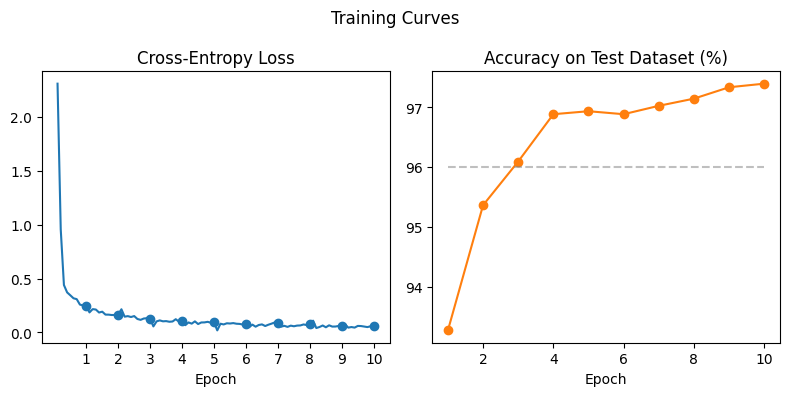

In [7]:
# create the network
network = MLP()

################################################
# Try to find the best hyperparameters for the following two values.
# Your MLP is also a hyperparameter. You can build it in any way you want.
# TODO
learning_rate = 0.001
batch_size = 64


################################################
# Create the train and test data loader.
# Enable num_workers=4 and persistent_workers for faster data loading.
# Also, shuffle the training data.
# TODO
training_loader = torch.utils.data.DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    persistent_workers=True
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    persistent_workers=True
)
################################################

optimizer = optim.Adam(network.parameters(), learning_rate)
epochs = 10 # Every student should (only) train for 10 epochs.

train_network(network, training_step, training_loader, test_loader, optimizer, epochs, baseline=96)

# Visualization
The computation that our neural networks do are hard to understand.
But we can look at the weights that directly operate on the raw pixel. Here we should see some interesting patterns.

🔹***Task:*** Run the code below.

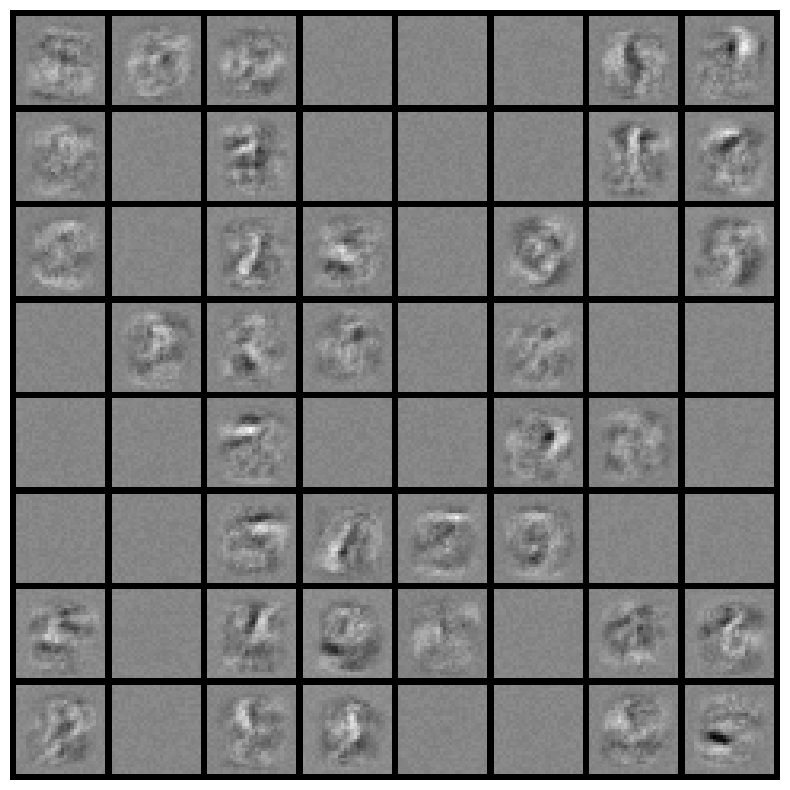

In [8]:
visualize_linear1_weights_2d(network, input_shape=(1, 28, 28))